# directly run the code to reproduce  visualization results (figure 1, 3 and 4)

In [12]:
import os
import torch
import argparse
import numpy as np
import sys
import time
from tqdm import tqdm
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
plt.rc('font',family='Times New Roman') 

import umap                        
import seaborn as sns 

# load imputed result

In [13]:
data1 = np.load('./result_npy/DPS_not_SP500_case1.npy')
data2 = np.load('./result_npy/DPS_not_SP500_case2.npy')
data3 = np.load('./result_npy/DPS_not_SP500_case3.npy')

# data1 = np.load('./result_npy/DPS_not_ETT_case1.npy')
# data2 = np.load('./result_npy/DPS_not_ETT_case2.npy')
# data3 = np.load('./result_npy/DPS_not_ETT_case3.npy')

# data1 = np.load('./result_npy/DPS_not_ER_case1.npy')
# data2 = np.load('./result_npy/DPS_not_ER_case2.npy')
# data3 = np.load('./result_npy/DPS_not_ER_case3.npy')

# data1 = np.load('./result_npy/DPS_not_Energy_case1.npy')
# data2 = np.load('./result_npy/DPS_not_Energy_case2.npy')
# data3 = np.load('./result_npy/DPS_not_Energy_case3.npy')

# data1 = np.load('./result_npy/DPS_not_Weather_case1.npy')
# data2 = np.load('./result_npy/DPS_not_Weather_case2.npy')
# data3 = np.load('./result_npy/DPS_not_Weather_case3.npy')


In [14]:
plt_sample_1 = data1[0]
plt_real_1   = data1[1]
plt_ob_1     = data1[1] * data1[2] 
plt_ob_1[plt_ob_1==0] = np.nan


plt_sample_2 = data2[0]
plt_real_2   = data2[1]
plt_ob_2     = data2[1] * data2[2] 
plt_ob_2[plt_ob_2==0] = np.nan


plt_sample_3 = data3[0]
plt_real_3   = data3[1]
plt_ob_3     = data3[1] * data3[2] 
plt_ob_3[plt_ob_3==0] = np.nan

# drawn figure 1 when there are at least on observed values 

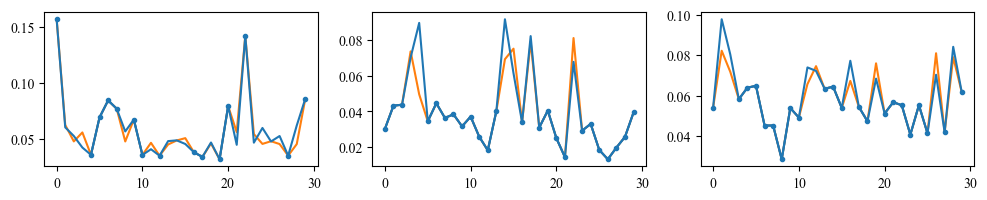

In [15]:
Number = data1[0].shape[0]
Attribute = data1[0].shape[2]

sample_ind1 = 443
attr_ind1 = 2

sample_ind2 = 255
attr_ind2 = 2

sample_ind3 = 134
attr_ind3 = 2


fig = plt.figure(figsize=(12,2))
plt.subplot(1,3,1)
plt.plot( plt_sample_1[sample_ind1][ :, attr_ind1],  c='#ff7f0e', alpha=1,)   
plt.plot( plt_ob_1[sample_ind1][:,attr_ind1],  c='#1f77b4', alpha=1, marker='o', markersize='3', )   
plt.plot( plt_real_1[sample_ind1][ :, attr_ind1],  c='#1f77b4', alpha=1,  )   
# plt.title('MNAR Case1')
# plt.ylabel("SP500",fontsize=15 )


plt.subplot(1,3,2)
plt.plot( plt_sample_2[sample_ind2][ :, attr_ind2],  c='#ff7f0e', alpha=1,)   
plt.plot( plt_ob_2[sample_ind2][:,attr_ind2],  c='#1f77b4', alpha=1, marker='o', markersize='3', )   
plt.plot( plt_real_2[sample_ind2][ :, attr_ind2],  c='#1f77b4', alpha=1,  )    
# plt.title('MNAR Case2')

plt.subplot(1,3,3)
plt.plot( plt_sample_3[sample_ind3][ :, attr_ind3],  c='#ff7f0e', alpha=1,)  
plt.plot( plt_ob_3[sample_ind3][:,attr_ind3],  c='#1f77b4', alpha=1, marker='o', markersize='3', )   
plt.plot( plt_real_3[sample_ind3][ :, attr_ind3],  c='#1f77b4', alpha=1,  )    
# plt.title('MNAR Case3')



# drawn figure 3 when some attributes are completely missing 

379 237 451


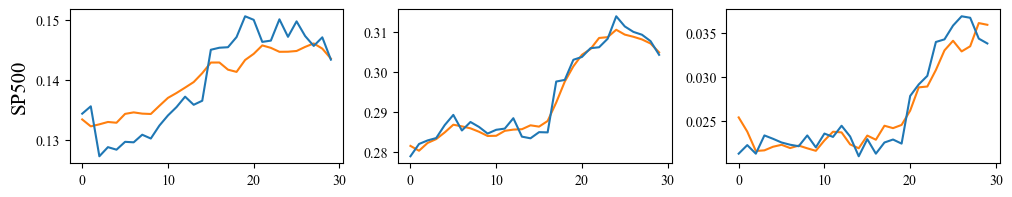

In [16]:
Number = data1[0].shape[0]
Attribute = data1[0].shape[2]


sample_ind1 = 379
attr_ind1 = 0

sample_ind2 = 237
attr_ind2 = 0

sample_ind3 = 451
attr_ind3 = 0
print( sample_ind1, sample_ind2, sample_ind3  )


fig = plt.figure(figsize=(12,2))
plt.subplot(1,3,1)
plt.plot( plt_sample_1[sample_ind1][ :, attr_ind1],  c='#ff7f0e', alpha=1,)   
plt.plot( plt_ob_1[sample_ind1][:,attr_ind1],  c='#1f77b4', alpha=1, marker='o', markersize='3', )   
plt.plot( plt_real_1[sample_ind1][ :, attr_ind1],  c='#1f77b4', alpha=1,  )    
# plt.title('MNAR Case1')
plt.ylabel("SP500",fontsize=15 )


plt.subplot(1,3,2)
plt.plot( plt_sample_2[sample_ind2][ :, attr_ind2],  c='#ff7f0e', alpha=1,)   
plt.plot( plt_ob_2[sample_ind2][:,attr_ind2],  c='#1f77b4', alpha=1, marker='o', markersize='3', )   
plt.plot( plt_real_2[sample_ind2][ :, attr_ind2],  c='#1f77b4', alpha=1,  )    
# plt.title('MNAR Case2')

plt.subplot(1,3,3)
plt.plot( plt_sample_3[sample_ind3][ :, attr_ind3],  c='#ff7f0e', alpha=1,)  
plt.plot( plt_ob_3[sample_ind3][:,attr_ind3],  c='#1f77b4', alpha=1, marker='o', markersize='3', )   
plt.plot( plt_real_3[sample_ind3][ :, attr_ind3],  c='#1f77b4', alpha=1,  )    
# plt.title('MNAR Case3')

# visualization by PCA, t-SNE, UMAP and KDE
# here we only test on 500 samples. Figure 4 can be reproduced on all samples. 

C:\Users\PC123\anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.000s...
[t-SNE] Computed neighbors for 1000 samples in 0.022s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 0.035228
[t-SNE] KL divergence after 250 iterations with early exaggeration: 48.191162
[t-SNE] KL divergence after 500 iterations: 0.274378


C:\Users\PC123\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\PC123\anaconda3\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\PC123\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)
C:\Users\PC123\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `k

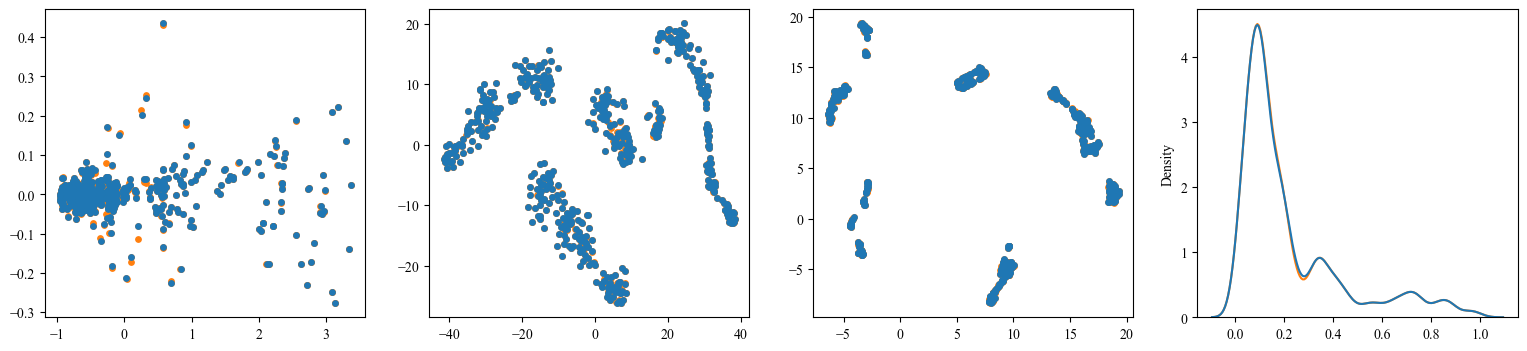

In [17]:
def visualization2(ori, gen):  
    Number = ori.shape[0]
    max_sample = min([4000, Number])       
    idx = np.random.permutation(Number)[ :max_sample]
    ori1 = np.asarray(ori)[idx]
    gen1 = np.asarray(gen)[idx]
    ori1 = np.mean(ori1, 2) 
    gen1 = np.mean(gen1, 2) 

    concat_data = np.concatenate((ori1, gen1), axis=0)
    pca = PCA(2)     
    pca_res = pca.fit_transform(concat_data)
    tsne = TSNE(n_components=2, verbose=1, perplexity=40,random_state=20,n_iter=500) 
    tsne_res = tsne.fit_transform(concat_data) 
    umap_ = umap.UMAP(random_state=42)
    umap_res = umap_.fit_transform(concat_data)
    fig = plt.figure(figsize=(19,4))
    plt.subplot(1,4,1)
    

    plt.scatter(pca_res[:2000,0],pca_res[:2000,1], s=15, c='#ff7f0e')
    plt.scatter(pca_res[max_sample:max_sample+2000,0],pca_res[max_sample:max_sample+2000,1], s=15, c='#1f77b4')
#     plt.xlabel('(a)',fontsize=25)
#     plt.ylabel('Weather', fontsize=25)
#     plt.title('PCA', fontsize=25)
    
    
    plt.subplot(1,4,2)
    plt.scatter(tsne_res[:2000,0],tsne_res[:2000,1],  s=15,  c='#ff7f0e')
    plt.scatter(tsne_res[max_sample:max_sample+2000,0],tsne_res[max_sample:max_sample+2000,1], s=15, c='#1f77b4')
#     plt.xlabel('(b)',fontsize=25)
#     plt.title('t-SNE', fontsize=25)
    
    plt.subplot(1,4,3)
    plt.scatter(umap_res[:2000, 0], umap_res[:2000, 1],  cmap='Spectral', s=15,  c='#ff7f0e')
    plt.scatter(umap_res[max_sample:max_sample+2000, 0], umap_res[max_sample:max_sample+2000, 1],  cmap='Spectral', s=15, c='#1f77b4')
#     plt.xlabel('(c)',fontsize=25)
#     plt.title('UMAP', fontsize=25)
    
    plt.subplot(1,4,4)
    sns.distplot(ori[:,:,1], hist=False, color = '#ff7f0e' )
    sns.distplot(gen[:,:,1], hist=False, color = '#1f77b4' )  
#     plt.xlabel('(d)',fontsize=25)
#     plt.title('KDE', fontsize=25)
    

visualization2( data1[0], data1[1] )